Link Kaggle: https://www.kaggle.com/datasets/bricevergnou/spotify-recommendation/data

* **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.
* **danceability** : Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.
* **duration_ms** : The duration of the track in milliseconds.
* **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy.
* **instrumentalness** : Predicts whether a track contains no vocals. “Ooh” and “aah” sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly “vocal”. The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.
* **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation . E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on.
* **liveness** : Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.
* **loudness** : The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typical range between -60 and 0 db.
* **mode** : Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.
* **speechiness** : Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.
* **tempo** : The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.
* **time_signature** : An estimated overall time signature of a track. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure).
* **valence** : A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).


And the variable that has to be predicted :

* **liked** : 1 for liked songs , 0 for disliked songs

## IMPORT LIBRARY

In [2]:
import numpy as np
import pandas as pd    
import seaborn as sns
import json
import matplotlib.pyplot as plt

## DATA LOADING

In [3]:
df_data = pd.read_csv('data.csv')

## EDA

In [4]:
df_data.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


In [5]:
df_data.shape

(195, 14)

In [6]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      195 non-null    float64
 1   energy            195 non-null    float64
 2   key               195 non-null    int64  
 3   loudness          195 non-null    float64
 4   mode              195 non-null    int64  
 5   speechiness       195 non-null    float64
 6   acousticness      195 non-null    float64
 7   instrumentalness  195 non-null    float64
 8   liveness          195 non-null    float64
 9   valence           195 non-null    float64
 10  tempo             195 non-null    float64
 11  duration_ms       195 non-null    int64  
 12  time_signature    195 non-null    int64  
 13  liked             195 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 21.5 KB


Seperti yang dilihat, bahwa tidak ada data yang null tetapi file csv ini tidak memiliki ID lagu. Dimana Untuk rekomendasi, diperlukan ID atau nama lagu untuk dapat direkomendasikan kepada pengguna

Jadi, disini saya akan membaca file json dan mengonversinya menjadi dataframe pandas

## load data json

In [7]:
# good.json songs
with open('good.json', 'r') as f:
    data = json.load(f)
good_df = pd.DataFrame(data['audio_features'])
good_df.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,0.749,0.839,6,-4.847,1,0.297,0.0867,0.000000,0.2040,0.804,172.068,audio_features,55mcupbf7cIsuCEVAuTJVk,spotify:track:55mcupbf7cIsuCEVAuTJVk,https://api.spotify.com/v1/tracks/55mcupbf7cIs...,https://api.spotify.com/v1/audio-analysis/55mc...,111000,4
1,0.573,0.581,10,-9.026,0,0.339,0.7530,0.000001,0.1300,0.351,76.506,audio_features,57RtLWT7IpugV0yi5bsxJk,spotify:track:57RtLWT7IpugV0yi5bsxJk,https://api.spotify.com/v1/tracks/57RtLWT7Ipug...,https://api.spotify.com/v1/audio-analysis/57Rt...,169347,4
2,0.800,0.719,7,-6.262,1,0.234,0.1090,0.000000,0.0580,0.815,143.975,audio_features,5VyfAfp2Yt3qaeuvq55ll3,spotify:track:5VyfAfp2Yt3qaeuvq55ll3,https://api.spotify.com/v1/tracks/5VyfAfp2Yt3q...,https://api.spotify.com/v1/audio-analysis/5Vyf...,230854,4
3,0.778,0.632,8,-6.415,1,0.125,0.0404,0.000000,0.0912,0.827,140.951,audio_features,3eWHY75nDgte70hh5yf4UW,spotify:track:3eWHY75nDgte70hh5yf4UW,https://api.spotify.com/v1/tracks/3eWHY75nDgte...,https://api.spotify.com/v1/audio-analysis/3eWH...,224029,4
4,0.797,0.852,8,-5.202,1,0.241,0.0555,0.000024,0.0536,0.480,136.035,audio_features,2UwrB6Ge6mPfUV8yGvAfX7,spotify:track:2UwrB6Ge6mPfUV8yGvAfX7,https://api.spotify.com/v1/tracks/2UwrB6Ge6mPf...,https://api.spotify.com/v1/audio-analysis/2Uwr...,102353,4


terdapat beberapa fitur yang tidak diperlukan dalam data seperti type, URI, https, URL sehingga akan saya drop

In [8]:
good_df = good_df.drop(columns=['type','uri','track_href','analysis_url'])

In [9]:
good_df.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature
0,0.749,0.839,6,-4.847,1,0.297,0.0867,0.000000,0.2040,0.804,172.068,55mcupbf7cIsuCEVAuTJVk,111000,4
1,0.573,0.581,10,-9.026,0,0.339,0.7530,0.000001,0.1300,0.351,76.506,57RtLWT7IpugV0yi5bsxJk,169347,4
2,0.800,0.719,7,-6.262,1,0.234,0.1090,0.000000,0.0580,0.815,143.975,5VyfAfp2Yt3qaeuvq55ll3,230854,4
3,0.778,0.632,8,-6.415,1,0.125,0.0404,0.000000,0.0912,0.827,140.951,3eWHY75nDgte70hh5yf4UW,224029,4
4,0.797,0.852,8,-5.202,1,0.241,0.0555,0.000024,0.0536,0.480,136.035,2UwrB6Ge6mPfUV8yGvAfX7,102353,4


In [10]:
# dislike.json songs
with open('dislike.json', 'r') as f:
    data = json.load(f)
dislike_df = pd.DataFrame(data['audio_features'])
dislike_df.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,0.357,0.980,6,-6.835,1,0.0790,0.000052,0.843,0.0768,0.368,96.969,audio_features,4pFC6tuWErxbO61oFFq3BQ,spotify:track:4pFC6tuWErxbO61oFFq3BQ,https://api.spotify.com/v1/tracks/4pFC6tuWErxb...,https://api.spotify.com/v1/audio-analysis/4pFC...,242760,4
1,0.446,0.977,10,-5.036,0,0.0781,0.000535,0.472,0.1050,0.339,172.059,audio_features,6V3SNkvi4BnfmZU0j7s9TQ,spotify:track:6V3SNkvi4BnfmZU0j7s9TQ,https://api.spotify.com/v1/tracks/6V3SNkvi4Bnf...,https://api.spotify.com/v1/audio-analysis/6V3S...,284400,4
2,0.291,0.980,1,-5.138,1,0.1530,0.001270,0.091,0.1020,0.257,79.792,audio_features,1Ds58cpyJzL0YTKk02vh1C,spotify:track:1Ds58cpyJzL0YTKk02vh1C,https://api.spotify.com/v1/tracks/1Ds58cpyJzL0...,https://api.spotify.com/v1/audio-analysis/1Ds5...,270920,4
3,0.462,0.974,1,-5.820,1,0.0816,0.000029,0.723,0.0751,0.399,107.877,audio_features,77QKNMGwlnzxsTZPYfByMu,spotify:track:77QKNMGwlnzxsTZPYfByMu,https://api.spotify.com/v1/tracks/77QKNMGwlnzx...,https://api.spotify.com/v1/audio-analysis/77QK...,186576,3
4,0.338,0.988,8,-7.290,0,0.0865,0.000083,0.833,0.0377,0.449,99.046,audio_features,3bQoMbPYOvvseHaSOWAQ3Q,spotify:track:3bQoMbPYOvvseHaSOWAQ3Q,https://api.spotify.com/v1/tracks/3bQoMbPYOvvs...,https://api.spotify.com/v1/audio-analysis/3bQo...,221960,4


In [11]:
dislike_df = dislike_df.drop(columns=['type','uri','track_href','analysis_url'])

In [12]:
dislike_df.head(5)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature
0,0.357,0.980,6,-6.835,1,0.0790,0.000052,0.843,0.0768,0.368,96.969,4pFC6tuWErxbO61oFFq3BQ,242760,4
1,0.446,0.977,10,-5.036,0,0.0781,0.000535,0.472,0.1050,0.339,172.059,6V3SNkvi4BnfmZU0j7s9TQ,284400,4
2,0.291,0.980,1,-5.138,1,0.1530,0.001270,0.091,0.1020,0.257,79.792,1Ds58cpyJzL0YTKk02vh1C,270920,4
3,0.462,0.974,1,-5.820,1,0.0816,0.000029,0.723,0.0751,0.399,107.877,77QKNMGwlnzxsTZPYfByMu,186576,3
4,0.338,0.988,8,-7.290,0,0.0865,0.000083,0.833,0.0377,0.449,99.046,3bQoMbPYOvvseHaSOWAQ3Q,221960,4


Lalu, saya juga menambah fitur like untuk menunjukkan apakah lagu itu good atau tidak.

In [13]:
good_df['like'] = 1
good_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature,like
0,0.749,0.839,6,-4.847,1,0.2970,0.0867,0.000000,0.2040,0.804,172.068,55mcupbf7cIsuCEVAuTJVk,111000,4,1
1,0.573,0.581,10,-9.026,0,0.3390,0.7530,0.000001,0.1300,0.351,76.506,57RtLWT7IpugV0yi5bsxJk,169347,4,1
2,0.800,0.719,7,-6.262,1,0.2340,0.1090,0.000000,0.0580,0.815,143.975,5VyfAfp2Yt3qaeuvq55ll3,230854,4,1
3,0.778,0.632,8,-6.415,1,0.1250,0.0404,0.000000,0.0912,0.827,140.951,3eWHY75nDgte70hh5yf4UW,224029,4,1
4,0.797,0.852,8,-5.202,1,0.2410,0.0555,0.000024,0.0536,0.480,136.035,2UwrB6Ge6mPfUV8yGvAfX7,102353,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.616,0.534,10,-10.264,0,0.4830,0.6390,0.000000,0.0844,0.556,170.054,3dl4lXWlOxnGo94OqNtpdq,146480,4,1
96,0.802,0.549,5,-8.600,0,0.0631,0.2680,0.004960,0.0984,0.498,138.984,3DWDcsDoXRIFynCREIkibM,184627,4,1
97,0.767,0.659,7,-4.541,1,0.0387,0.7850,0.000000,0.1120,0.631,90.056,6fmtZEUoGwxPNvUgr0NJm1,186720,4,1
98,0.752,0.468,0,-9.966,1,0.3330,0.8050,0.000000,0.1360,0.716,82.795,2edc1m7WXxdBA61WlxSInp,179253,4,1


In [14]:
dislike_df['like'] = 0
dislike_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature,like
0,0.357,0.980,6,-6.835,1,0.0790,0.000052,0.843000,0.0768,0.368,96.969,4pFC6tuWErxbO61oFFq3BQ,242760,4,0
1,0.446,0.977,10,-5.036,0,0.0781,0.000535,0.472000,0.1050,0.339,172.059,6V3SNkvi4BnfmZU0j7s9TQ,284400,4,0
2,0.291,0.980,1,-5.138,1,0.1530,0.001270,0.091000,0.1020,0.257,79.792,1Ds58cpyJzL0YTKk02vh1C,270920,4,0
3,0.462,0.974,1,-5.820,1,0.0816,0.000029,0.723000,0.0751,0.399,107.877,77QKNMGwlnzxsTZPYfByMu,186576,3,0
4,0.338,0.988,8,-7.290,0,0.0865,0.000083,0.833000,0.0377,0.449,99.046,3bQoMbPYOvvseHaSOWAQ3Q,221960,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0.798,0.746,10,-8.639,1,0.0313,0.030400,0.361000,0.0703,0.965,128.553,1QqsAlhs7pxcXs9BMB1Nv5,655213,4,0
91,0.651,0.811,10,-13.870,1,0.0318,0.064800,0.029300,0.1000,0.962,112.126,6VuIKS2Z27jCutIapgCUZF,186573,4,0
92,0.705,0.847,6,-2.588,1,0.0361,0.414000,0.000003,0.4060,0.743,120.527,7sMGwiS4vOMcz86ZY3vKYM,228120,4,0
93,0.819,0.811,6,-7.760,0,0.0349,0.203000,0.005580,0.1390,0.766,106.684,4JsQkSOE4taeyhH3pv1een,246760,4,0


lalu saya menggabungkan kedua dataframe tersebut

In [15]:
df = pd.concat([good_df,dislike_df])
df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature,like
0,0.749,0.839,6,-4.847,1,0.2970,0.0867,0.000000,0.2040,0.804,172.068,55mcupbf7cIsuCEVAuTJVk,111000,4,1
1,0.573,0.581,10,-9.026,0,0.3390,0.7530,0.000001,0.1300,0.351,76.506,57RtLWT7IpugV0yi5bsxJk,169347,4,1
2,0.800,0.719,7,-6.262,1,0.2340,0.1090,0.000000,0.0580,0.815,143.975,5VyfAfp2Yt3qaeuvq55ll3,230854,4,1
3,0.778,0.632,8,-6.415,1,0.1250,0.0404,0.000000,0.0912,0.827,140.951,3eWHY75nDgte70hh5yf4UW,224029,4,1
4,0.797,0.852,8,-5.202,1,0.2410,0.0555,0.000024,0.0536,0.480,136.035,2UwrB6Ge6mPfUV8yGvAfX7,102353,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0.798,0.746,10,-8.639,1,0.0313,0.0304,0.361000,0.0703,0.965,128.553,1QqsAlhs7pxcXs9BMB1Nv5,655213,4,0
91,0.651,0.811,10,-13.870,1,0.0318,0.0648,0.029300,0.1000,0.962,112.126,6VuIKS2Z27jCutIapgCUZF,186573,4,0
92,0.705,0.847,6,-2.588,1,0.0361,0.4140,0.000003,0.4060,0.743,120.527,7sMGwiS4vOMcz86ZY3vKYM,228120,4,0
93,0.819,0.811,6,-7.760,0,0.0349,0.2030,0.005580,0.1390,0.766,106.684,4JsQkSOE4taeyhH3pv1een,246760,4,0


array([[<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>],
       [<Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'duration_ms'}>],
       [<Axes: title={'center': 'time_signature'}>,
        <Axes: title={'center': 'like'}>, <Axes: >, <Axes: >]],
      dtype=object)

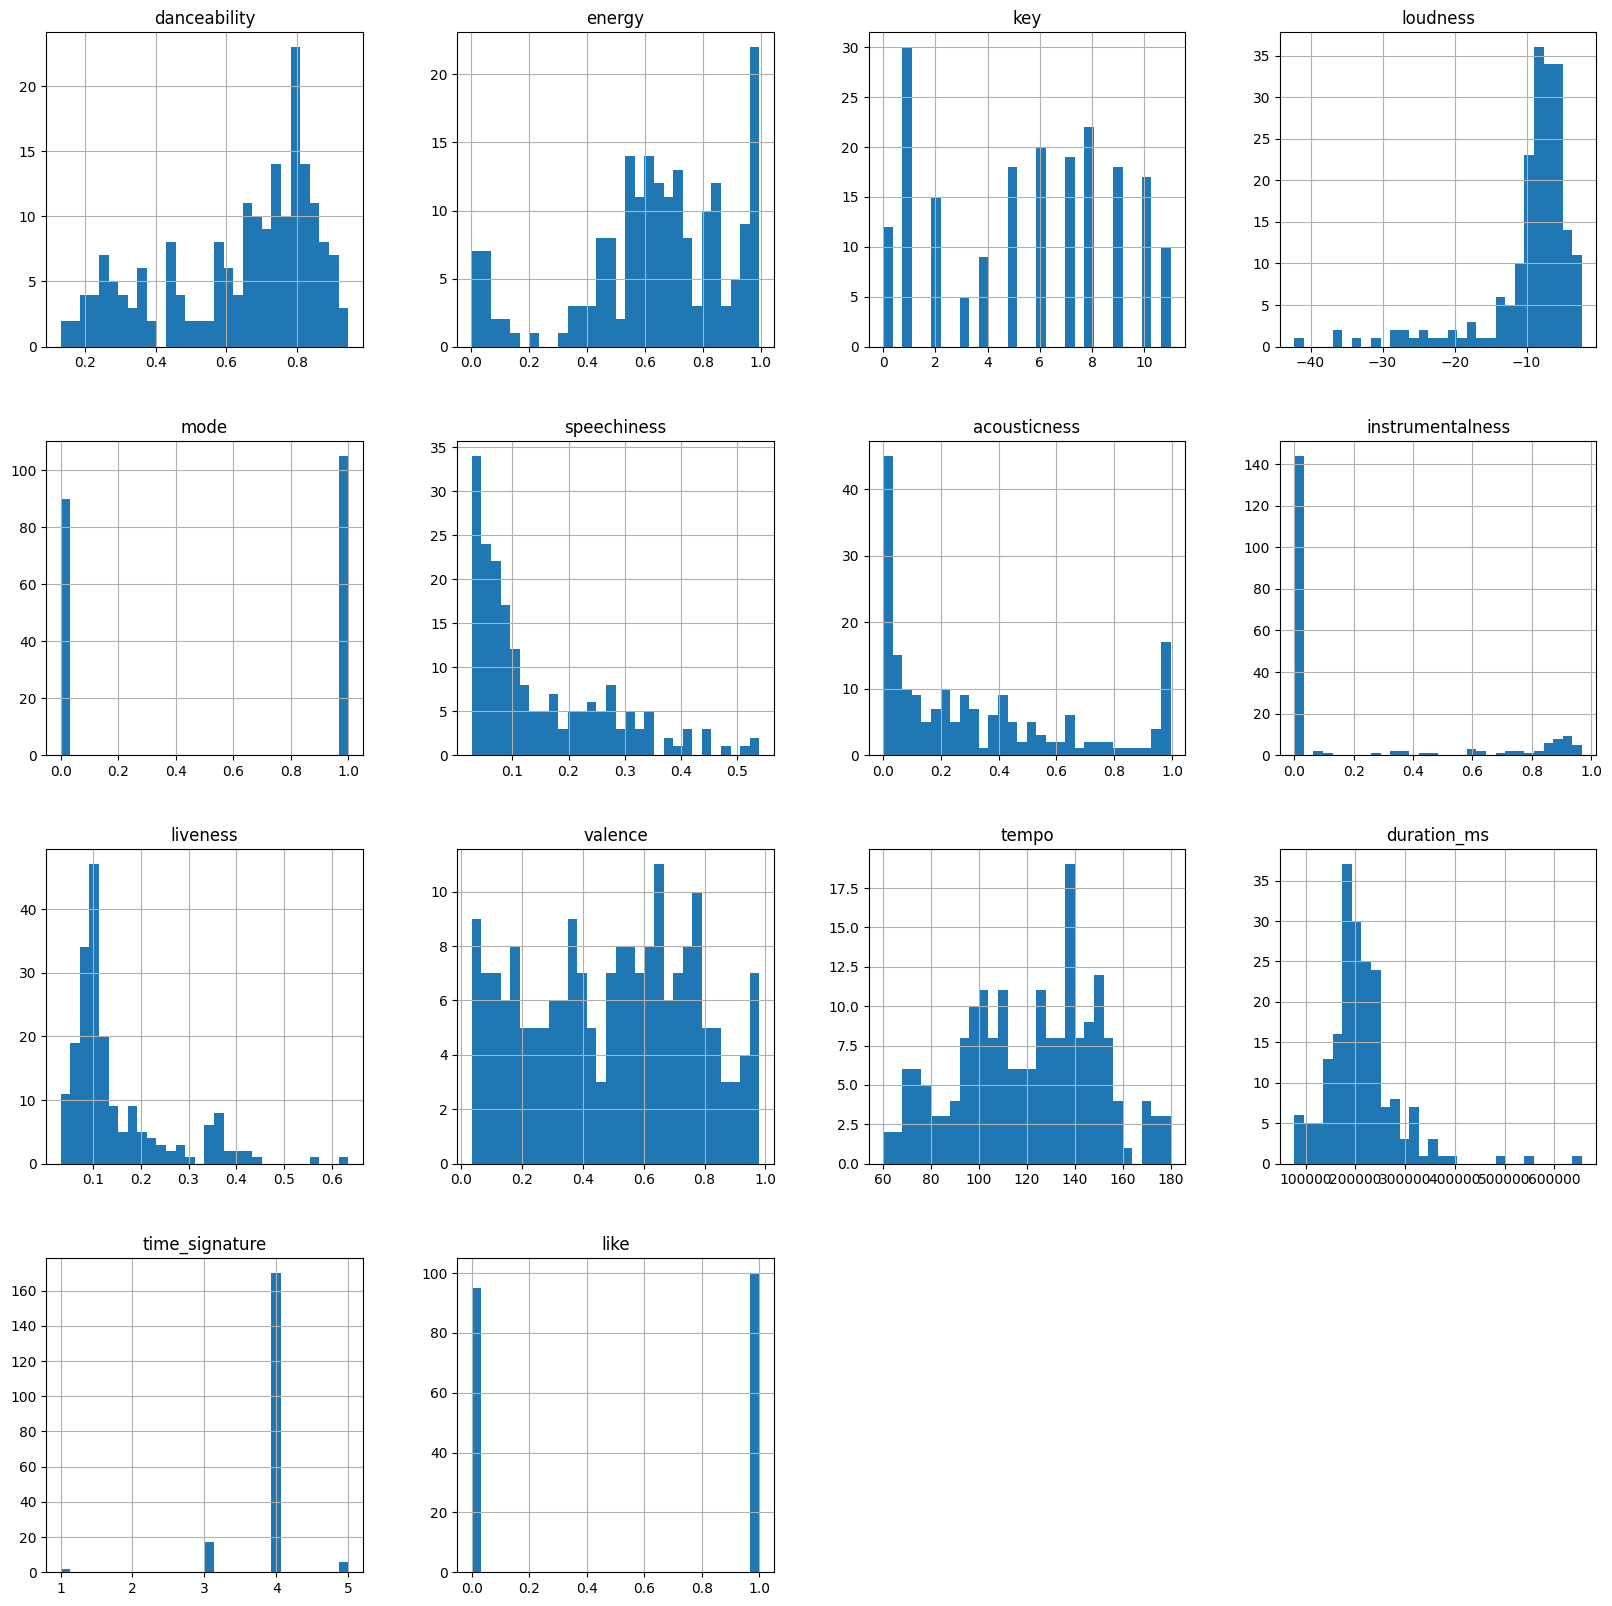

In [16]:
df.hist(bins=30, figsize=(20,20))

Melihat bagaimana boxplot tiap fitur terhadap like

<Axes: xlabel='like', ylabel='count'>

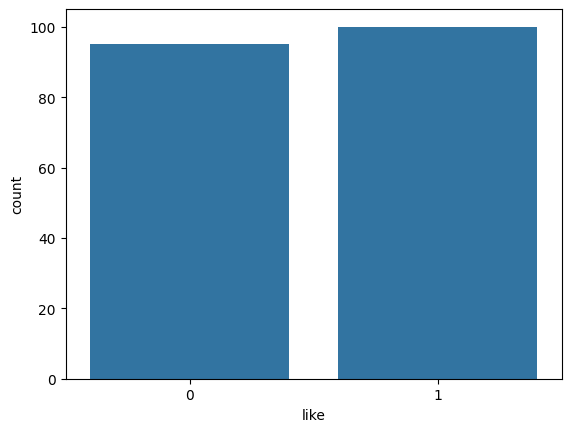

In [17]:
sns.countplot(data=df, x='like')

<Axes: xlabel='like', ylabel='danceability'>

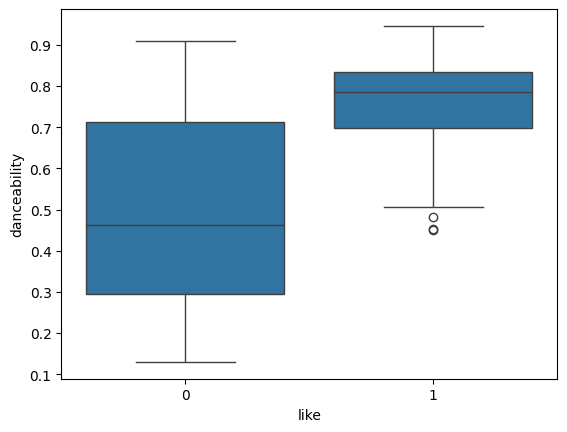

In [18]:
sns.boxplot(data=df, x='like', y='danceability')

<Axes: xlabel='like', ylabel='loudness'>

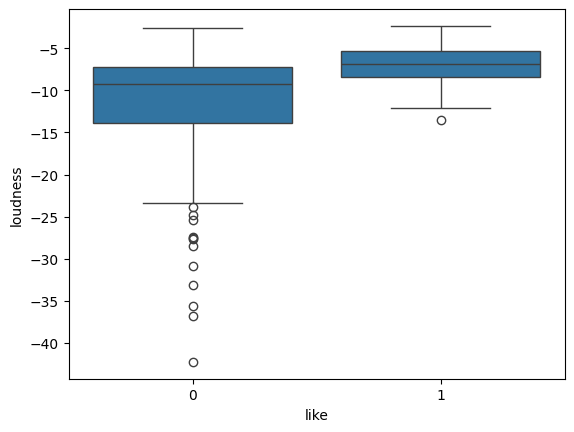

In [19]:
sns.boxplot(data=df, x='like', y='loudness')

<Axes: xlabel='like', ylabel='duration_ms'>

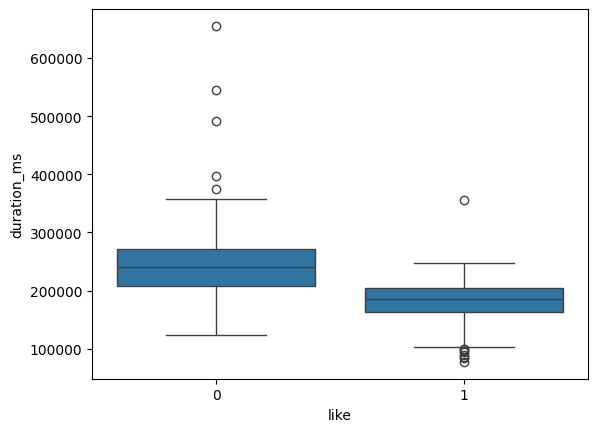

In [20]:
sns.boxplot(data=df, x='like', y='duration_ms')

<Axes: xlabel='loudness', ylabel='energy'>

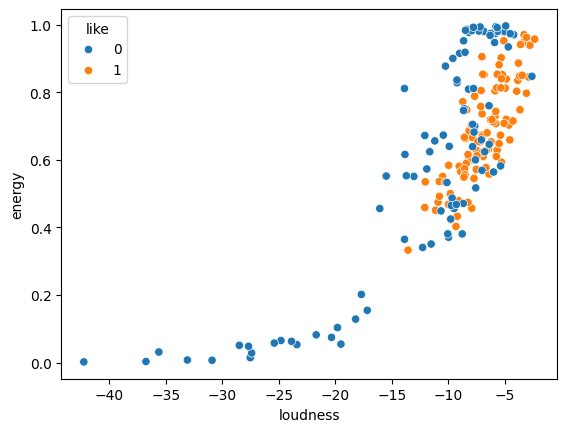

In [21]:
sns.scatterplot(data=df, x='loudness', y='energy', hue='like')

<Axes: xlabel='danceability', ylabel='valence'>

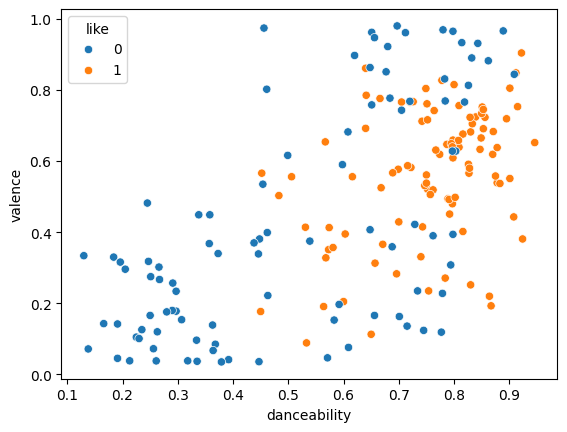

In [22]:
sns.scatterplot(data=df, x='danceability', y='valence', hue='like')

Semakin valance(positif) dan danceability semakin banyak like nya

Melihat Korelasi antar tiap fitur

In [23]:
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms','like', 'time_signature']
df_new = df[features]

<Axes: >

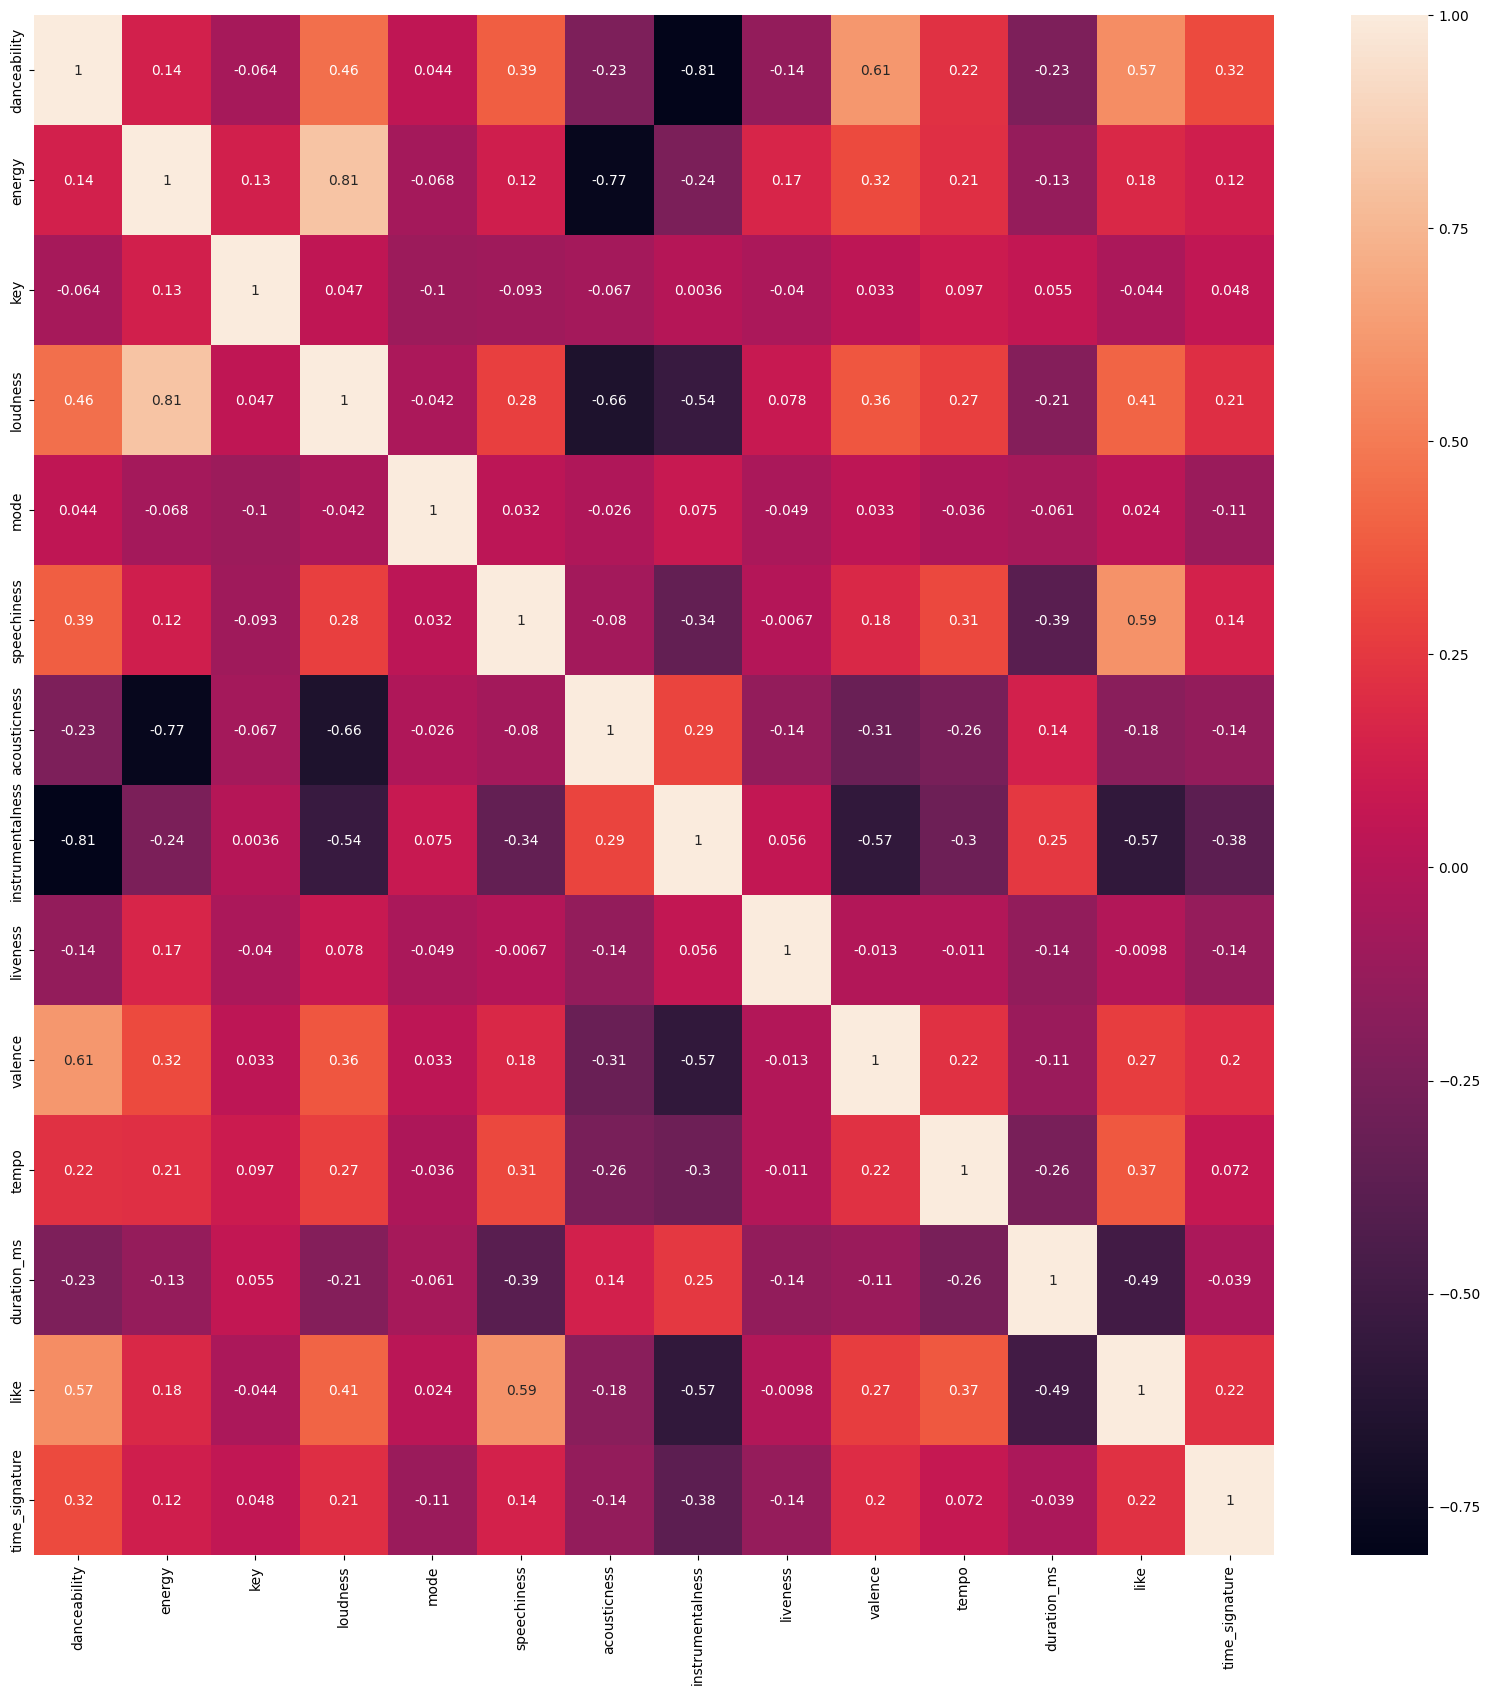

In [24]:
correlations = df_new.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlations, annot=True)

In [25]:
print(correlations['like'].sort_values(ascending=False))

like                1.000000
speechiness         0.591505
danceability        0.569425
loudness            0.410774
tempo               0.371202
valence             0.268653
time_signature      0.221479
energy              0.176179
mode                0.023747
liveness           -0.009797
key                -0.044406
acousticness       -0.179375
duration_ms        -0.490651
instrumentalness   -0.569440
Name: like, dtype: float64


1. Fitur dengan korelasi positif kuat terhadap like:
- Speechiness (0.59): Lagu dengan lebih banyak elemen lirik atau vokal cenderung lebih disukai.
- Danceability (0.57): Lagu yang lebih cocok untuk menari cenderung lebih disukai.
- Loudness (0.41): Lagu yang lebih keras (dalam dB) lebih disukai.
- Tempo (0.37): Lagu dengan tempo lebih cepat sedikit lebih disukai.
- Valence (0.27): Lagu yang terdengar lebih positif atau ceria lebih disukai.
- Energy (0.18) → Lagu yang lebih "energetic" agak disukai, tetapi tidak signifikan.
- Time Signature (0.22) → Struktur ketukan lagu sedikit berpengaruh, tapi tidak begitu berpengaruh.

2. Fitur dengan korelasi negatif kuat terhadap like:
- Instrumentalness (-0.57): Lagu yang lebih banyak instrumental cenderung kurang disukai.
- Duration_ms (-0.49): Lagu yang lebih panjang cenderung kurang disukai.
- Acousticness (-0.18): Lagu yang lebih akustik sedikit kurang disukai.

3. Fitur dengan korelasi lemah atau hampir tidak berpengaruh:
Mode (0.02), Liveness (-0.01), Key (-0.04): Fitur-fitur ini memiliki pengaruh yang lebih kecil terhadap kesukaan lagu.

In [26]:
from yes import yes_ids
from no import no_ids

In [27]:
# masukkan nama lagu berdasarkaan id nya
id_to_name = {track['track']['id']: track['track']['name'] for track in yes_ids['items']}
id_to_name.update({track['track']['id']: track['track']['name'] for track in no_ids['items']})

In [28]:
df['song_name'] = df['id'].map(id_to_name).fillna("Unknown Song")

In [29]:
df.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,id,duration_ms,time_signature,like,song_name
0,0.749,0.839,6,-4.847,1,0.2970,0.0867,0.000000,0.2040,0.804,172.068,55mcupbf7cIsuCEVAuTJVk,111000,4,1,OVGTC - Star Wars remix
1,0.573,0.581,10,-9.026,0,0.3390,0.7530,0.000001,0.1300,0.351,76.506,57RtLWT7IpugV0yi5bsxJk,169347,4,1,Rêves de môme
2,0.800,0.719,7,-6.262,1,0.2340,0.1090,0.000000,0.0580,0.815,143.975,5VyfAfp2Yt3qaeuvq55ll3,230854,4,1,4 millions
3,0.778,0.632,8,-6.415,1,0.1250,0.0404,0.000000,0.0912,0.827,140.951,3eWHY75nDgte70hh5yf4UW,224029,4,1,Bandana mauve
4,0.797,0.852,8,-5.202,1,0.2410,0.0555,0.000024,0.0536,0.480,136.035,2UwrB6Ge6mPfUV8yGvAfX7,102353,4,1,Brothers (Remix Rilès)
5,0.743,0.663,2,-8.470,1,0.0507,0.0148,0.000666,0.3930,0.415,132.012,4HolRqFuNvTvoLR2l1gexi,100000,4,1,Challenge incroyable #2
6,0.915,0.551,8,-10.490,1,0.3430,0.0342,0.000000,0.1020,0.753,124.906,6dS1JCvtMJQ1O9bseVLyJz,88320,4,1,Freestyle Challenge
7,0.798,0.835,9,-3.832,1,0.2020,0.1650,0.000000,0.1120,0.609,150.040,3zCWbPJVp1egCgyoMYAsDN,139240,4,1,Electron libérable
8,0.827,0.804,9,-5.846,1,0.1280,0.4550,0.000001,0.2720,0.566,146.079,0O4U6fVE1TwWYhM4fKr1Fh,178588,4,1,WAW
9,0.830,0.707,2,-5.777,1,0.2770,0.1670,0.000000,0.0797,0.682,146.154,3yFf0EtFwkiVSbf8CK4CB3,190685,4,1,EN ATTENDANT


Dengan menggunakan metode 'Content-Based Filtering' maka saya akan membuat cosine similarit-nya

## Cosine similiarity

In [30]:
df_cs = df.drop(columns=['id', 'song_name'])
df_cs

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,like
0,0.749,0.839,6,-4.847,1,0.2970,0.0867,0.000000,0.2040,0.804,172.068,111000,4,1
1,0.573,0.581,10,-9.026,0,0.3390,0.7530,0.000001,0.1300,0.351,76.506,169347,4,1
2,0.800,0.719,7,-6.262,1,0.2340,0.1090,0.000000,0.0580,0.815,143.975,230854,4,1
3,0.778,0.632,8,-6.415,1,0.1250,0.0404,0.000000,0.0912,0.827,140.951,224029,4,1
4,0.797,0.852,8,-5.202,1,0.2410,0.0555,0.000024,0.0536,0.480,136.035,102353,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,0.798,0.746,10,-8.639,1,0.0313,0.0304,0.361000,0.0703,0.965,128.553,655213,4,0
91,0.651,0.811,10,-13.870,1,0.0318,0.0648,0.029300,0.1000,0.962,112.126,186573,4,0
92,0.705,0.847,6,-2.588,1,0.0361,0.4140,0.000003,0.4060,0.743,120.527,228120,4,0
93,0.819,0.811,6,-7.760,0,0.0349,0.2030,0.005580,0.1390,0.766,106.684,246760,4,0


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

cs = cosine_similarity(df_cs)
print(cs)

[[1.         0.9999994  0.99999957 ... 0.99999948 0.99999937 0.99999954]
 [0.9999994  1.         0.99999998 ... 1.         1.         0.99999999]
 [0.99999957 0.99999998 1.         ... 1.         0.99999998 1.        ]
 ...
 [0.99999948 1.         1.         ... 1.         1.         1.        ]
 [0.99999937 1.         0.99999998 ... 1.         1.         0.99999999]
 [0.99999954 0.99999999 1.         ... 1.         0.99999999 1.        ]]


### Membuat function untuk mencari rekomendasi lagu berdasarkan song_name dan ID

## SONG ID

In [32]:
def find_song_id(song_id):
    """Mencari lagu berdasarkan ID."""
    song_row = df[df["id"] == song_id]
    
    if song_row.empty:
        print("Lagu dengan ID tersebut tidak ditemukan.")
        return None, None
    
    return song_row.index[0], song_row.iloc[0]["song_name"]

def recommend_song_id(song_id, top_n=10):
    song_idx, song_title = find_song_id(song_id)
    if song_idx is None:
        return
    
    most_similar_idx = np.argsort(-cs[song_idx])[1:top_n+1]  
    recommended_songs = df.iloc[most_similar_idx][["id", "song_name"]]

    print(f"\nLagu yang diinput (ID: {song_id}): '{song_title}'")
    print("\nRekomendasi lagu serupa:\n", recommended_songs)


## SONG NAME

In [33]:
def find_song_name(song_name):
    """Mencari lagu berdasarkan judul."""
    song_row = df[df["song_name"].str.lower().str.strip() == song_name.lower().strip()]
    
    if song_row.empty:
        print("Lagu dengan judul tersebut tidak ditemukan.")
        return None, None

    return song_row.index[0], song_row.iloc[0]["song_name"]


def recommend_song_name(song_name, top_n=10):
    song_idx, song_name = find_song_name(song_name)
    if song_idx is None:
        return

    most_similar_idx = np.argsort(-cs[song_idx])[1:top_n+1] 
    recommended_songs = df.iloc[most_similar_idx][["id", "song_name"]]

    # Menampilkan hasil rekomendasi
    print(f"\nLagu yang diinput: '{song_name}'")
    print("\nRekomendasi lagu serupa:\n", recommended_songs)

Cari rekomendaasi Lagu

In [34]:
song_id1 = "55mcupbf7cIsuCEVAuTJVk"
recommend_song_id(song_id1)


Lagu yang diinput (ID: 55mcupbf7cIsuCEVAuTJVk): 'OVGTC - Star Wars remix'

Rekomendasi lagu serupa:
                         id                        song_name
22  0wSGClIhJMGkdamvWSTqX0   Les 7 péchés capitaux / Colère
62  6pjtY9QtWHxTqPkTfGW0ru          Nouveaux Hippies, Pt. 3
58  4W1RGS4ncIY1yrz38rysN3  Pistolet Rose 2 - A COLORS SHOW
77  5hlashYN7IwHpQ4PLtQNf4                           Batman
6   6dS1JCvtMJQ1O9bseVLyJz              Freestyle Challenge
4   2UwrB6Ge6mPfUV8yGvAfX7           Brothers (Remix Rilès)
5   4HolRqFuNvTvoLR2l1gexi          Challenge incroyable #2
33  07whpV2cnsEG3vk4qGxRQN             Challenge incroyable
95  3dl4lXWlOxnGo94OqNtpdq                          Mauvais
12  6tQB8rJfdvILrxIxuKIRMu       Christophe (Remix Orelsan)


In [35]:
song_id2 = "3P2zU7fEjnZRunH124QnJL"
recommend_song_id(song_id2)


Lagu yang diinput (ID: 3P2zU7fEjnZRunH124QnJL): 'That's the Way (I Like It) - Edit'

Rekomendasi lagu serupa:
                         id           song_name
91  2UREu1Y8CO4jXkbvqAtP7g             Monster
39  0De4Cl3YncrwWkqJiJfA7k                 PLM
88  4QMaRC93F0aFx3S648CLyh        Animal In Me
28  2MCAs3ttHSuDm1RHL0rqTF              Jamais
48  6mkAhxAj1y5zvXWefkd9y7  Toujours en retard
8   0O4U6fVE1TwWYhM4fKr1Fh                 WAW
75  1l4RFBJ96hKYXRBl9AWCVt             Fais-le
11  2ODYKhD4xlPViKP4LrNAwD          La marelle
57  1NW4kNeeaRl5xxOnOLsYIJ              Pareil
64  136fhifxcZQYs60Qgac9bm                Loin


In [36]:
recommend_song_id("3qjDXaWCalJ9ZzaHBG4j3V") 


Lagu yang diinput (ID: 3qjDXaWCalJ9ZzaHBG4j3V): 'Remise en forme'

Rekomendasi lagu serupa:
                         id         song_name
42  27x1z3kAL3Jx5TF4HyikPG    07 56 89 24 89
32  59wSo3BVsBDZWMRKLwTpdv  Tour de contrôle
8   0O4U6fVE1TwWYhM4fKr1Fh               WAW
68  2fl01uGwbppFEci7qij1lU             Y'a R
14  4zHabeonyLGTgnR9R5RY3X          Dimanche
56  6Fn1k9ctMXsh5xrrMRaGQZ           Matrice
89  0PieJw6d3jyki3JTxgZhIr           Watcher
38  6yE734jgKBYFAzymZ6Elal             Gamme
75  1l4RFBJ96hKYXRBl9AWCVt           Fais-le
57  1NW4kNeeaRl5xxOnOLsYIJ            Pareil


In [37]:
recommend_song_name("4 millions")


Lagu yang diinput: '4 millions'

Rekomendasi lagu serupa:
                         id                         song_name
3   3eWHY75nDgte70hh5yf4UW                     Bandana mauve
86  7Khbx8MgVTwIJe8YBi8tci                         No Stress
47  0HkoTr9t0f6MeqGoUS3E3e                             JOKER
17  0V5c3isfSfyl7zQDtV9fAp                     Forever Broke
1   6V3SNkvi4BnfmZU0j7s9TQ                   Scourge of Iron
21  27zu28YulIo7buGdzgN0bm                The Cryptic Stench
81  45oFq8ZKV9KDhzYb2Rh1y4           Maniac - BOF Flashdance
27  6u1rhQAvxkWLeuqUC3iJD0  J'turn up (feat. Alkpote et Njd)
90  3F1vWVOvzgKx7r5ZRp19gu                 Stress of Success
55  0jU7JpfPrm7jjaLjFLXZLh             T’as Compris L’Truc ?


In [38]:
recommend_song_name("Derniers réglages")


Lagu yang diinput: 'Derniers réglages'

Rekomendasi lagu serupa:
                         id                    song_name
72  73csFz02rFRAGhlV7wFajY  GROSSE BLETA (feat. Kaaris)
83  7e176FKv7cq6SG9EXYMLoQ    What Cha' Gonna Do for Me
24  67gauLFb25vQYR7qMhNnTT                   Disfigured
86  5zWZ9iNevP0397xB3jWV2z                Brother Louie
87  3DZnc4lcqJF8FJmRbjrmA0  I Like Chopin (Single Edit)
13  4sTDuXa8uGDHwJdsXUqIBo                   Understood
6   10nOWGyxyXW42t9NH6BNSS         Death Walking Terror
84  3yDhZq8f17SmumVmEyCaRN                   Give It Up
52  5HIaPHHvXP9D7lcDdFlvf9                   Perle Rare
35  4LAGHmHcSt0HHwXCJcFri6                         91's


In [39]:
recommend_song_name("Hammer Smashed Face")


Lagu yang diinput: 'Hammer Smashed Face'

Rekomendasi lagu serupa:
                         id                        song_name
22  0wSGClIhJMGkdamvWSTqX0   Les 7 péchés capitaux / Colère
62  6pjtY9QtWHxTqPkTfGW0ru          Nouveaux Hippies, Pt. 3
58  4W1RGS4ncIY1yrz38rysN3  Pistolet Rose 2 - A COLORS SHOW
77  5hlashYN7IwHpQ4PLtQNf4                           Batman
6   6dS1JCvtMJQ1O9bseVLyJz              Freestyle Challenge
4   2UwrB6Ge6mPfUV8yGvAfX7           Brothers (Remix Rilès)
5   4HolRqFuNvTvoLR2l1gexi          Challenge incroyable #2
33  07whpV2cnsEG3vk4qGxRQN             Challenge incroyable
95  3dl4lXWlOxnGo94OqNtpdq                          Mauvais
12  6tQB8rJfdvILrxIxuKIRMu       Christophe (Remix Orelsan)


In [40]:
# Menyimpan dataframe ke file CSV
output_file = 'Data_recommendationafter.csv'  
df.to_csv(output_file, index=False)

print(f"Hasil rekomendasi telah disimpan ke dalam file '{output_file}'.")

Hasil rekomendasi telah disimpan ke dalam file 'Data_recommendationafter.csv'.
